In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# ResNet-50

**Paper:** [arXiv:1512.03385](https://arxiv.org/pdf/1512.03385) — *Deep Residual Learning for Image Recognition* (He et al., Microsoft Research, 2015).  
**HF Source:** [timm/resnet50.a1_in1k](https://huggingface.co/timm/resnet50.a1_in1k)

This notebook walks through a **from-scratch JAX implementation** of ResNet-50.

---

### Paper Overview

ResNet's central contribution is the **residual (skip) connection** — instead of learning `H(x)` directly, each block learns the residual `F(x) = H(x) − x`, making it dramatically easier to optimise very deep networks.

| Innovation | What it solves |
|---|---|
| **Residual connections** | Eliminates vanishing gradients; enables 100+ layer networks |
| **Bottleneck block** | 1×1 → 3×3 → 1×1 structure reduces compute while increasing depth |
| **Batch Normalisation** | Stabilises training, enables higher learning rates |
| **Global Average Pooling** | Replaces large fully-connected layers, drastically cuts parameters |

### Architecture at a glance (ResNet-50)

```
Input (224×224×3)
  ↓  Stem: 7×7 conv, stride 2 → 64ch, 112×112 + BN + ReLU
  ↓  MaxPool 3×3, stride 2 → 64ch, 56×56
-------------------------------------------------------------------------
Stage 1: 3× Bottleneck (stride 1)          → 256ch,  56×56
Stage 2: 1× Bottleneck (s=2) + 3× (s=1)    → 512ch,  28×28
Stage 3: 1× Bottleneck (s=2) + 5× (s=1)    → 1024ch, 14×14
Stage 4: 1× Bottleneck (s=2) + 2× (s=1)    → 2048ch, 7×7
-------------------------------------------------------------------------
  ↓  Global Average Pool → (2048,)
  ↓  Linear → 1000 classes
```


### Imports

In [ ]:
import json
from dataclasses import dataclass

import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import PIL.Image as Image
from safetensors.numpy import load_file
from transformers import AutoTokenizer

**Setup:** Download the model weights and config from HuggingFace and place them at `models/resnet/` relative to your workspace root

In [ ]:
HF_REPO_ID = "timm/resnet50.a1_in1k"
LOCAL_DIR_PATH = "workspace/models/resnet"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)
print(f"Downloaded repository path: {local_dir}")

### Load Weights

ResNet-50 uses a **Bottleneck** design — each block is a 3-layer unit (`1×1 → 3×3 → 1×1`) rather than the plain 2-layer `3×3 → 3×3` used in ResNet-18/34. This design keeps parameter count manageable at greater depths by using the flanking 1×1 convs to compress and then expand channels around the expensive 3×3 conv.

The 50-layer depth comes from: 1 stem conv + 3+4+6+3 bottleneck blocks × 3 convs each + 1 final classifier = **50 layers**.

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
LABELS_PATH = f"{LOCAL_DIR_PATH}/id2label.json"
IMAGE_PATH = f"{LOCAL_DIR_PATH}/cat.png"

checkpoint_path = WEIGHTS_PATH
hf_weights = load_file(checkpoint_path)

### Weight Extraction

ResNet-50 has 4 stages with `[3, 4, 6, 3]` Bottleneck blocks respectively — **16 blocks total**, each containing:

- `conv1 / conv2 / conv3` — the three convolutions of the bottleneck (1×1 reduce, 3×3 spatial, 1×1 expand)
- `bn1 / bn2 / bn3` — Batch Normalisation after each of the three convolutions
- `downsample.0` / `downsample.1` — a projection conv + BN present **only on the first block of each stage**, used to match channel dimensions for the residual addition

The first block of every stage changes the channel count (e.g. 64 → 256 in Stage 1), so its shortcut path must project to the new channel count via the 1×1 downsample conv. All subsequent blocks within a stage leave channels unchanged and use a **zero-parameter identity shortcut**.

In [ ]:
def get_w(
    name: str,
    transpose: bool = False
):
    val = hf_weights.pop(name)
    w = jnp.array(val, dtype=jnp.bfloat16)
    return w.T if transpose else w

layers = []
num_layers = [3, 4, 6, 3]
for block in range(4):
    for layer in range(num_layers[block]):
        layer_dict = {
            'bn': [
                {
                    'weight': get_w(f'layer{block + 1}.{layer}.bn{k + 1}.weight'),
                    'bias': get_w(f'layer{block + 1}.{layer}.bn{k + 1}.bias'),
                    'running_mean': get_w(f'layer{block + 1}.{layer}.bn{k + 1}.running_mean'),
                    'running_var': get_w(f'layer{block + 1}.{layer}.bn{k + 1}.running_var')
                } for k in range(3)
            ],
            'conv': [
                get_w(f'layer{block + 1}.{layer}.conv{k + 1}.weight') for k in range(3)
            ],
        }
        if layer == 0:
            layer_dict['downsample'] = {
                'conv': get_w(f'layer{block + 1}.{layer}.downsample.0.weight'),
                'bn': {
                    'weight': get_w(f'layer{block + 1}.{layer}.downsample.1.weight'),
                    'bias': get_w(f'layer{block + 1}.{layer}.downsample.1.bias'),
                        'running_mean': get_w(f'layer{block + 1}.{layer}.downsample.1.running_mean'),
                        'running_var': get_w(f'layer{block + 1}.{layer}.downsample.1.running_var')
                    }
                }
        layers.append(layer_dict)

m = {
    'bn': {
        'weight': get_w('bn1.weight'),
        'bias': get_w('bn1.bias'),
        'running_mean': get_w('bn1.running_mean'),
        'running_var': get_w('bn1.running_var')
    },
    'conv': get_w('conv1.weight'),
    'fc': {
        'weight': get_w('fc.weight'),
        'bias': get_w('fc.bias')
    },
    'blocks': layers
}


### Preprocessing

ResNet was trained on ImageNet with per-channel mean/std normalisation — the values `[0.485, 0.456, 0.406]` and `[0.229, 0.224, 0.225]` are the **ImageNet dataset statistics** (mean and std of RGB channels across the training set). Using these is required to match the distribution the weights were trained on.

The input is resized to `224×224` and transposed from HWC (PIL/NumPy convention) to **NCHW** (channels-first), which is what JAX's `conv_general_dilated` expects with `dimension_numbers=('NCHW', 'OIHW', 'NCHW')`.

In [95]:
def preprocess(
    image_path: str,
    target_size: tuple = (224, 224)
):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(
        (target_size[1], target_size[0]), 
        resample=Image.BICUBIC
    )
    x = jnp.array(np.array(img_resized), dtype=jnp.float32) / 255.0
    mean = jnp.array([0.485, 0.456, 0.406])
    std = jnp.array([0.229, 0.224, 0.225])
    x = (x - mean) / std
    x = x.astype(jnp.bfloat16)
    x = x[None, ...]
    x = x.transpose(0, 3, 1, 2)
    return x


### Batch Normalisation

**Section 3 (He et al.):** ResNet was one of the early architectures to use Batch Normalisation (Ioffe & Szegedy, 2015) pervasively — every conv is followed by BN + ReLU before the next layer.

At **inference time**, BN uses the **running statistics** (accumulated during training) rather than the per-batch mean/variance. The operation is:

$$\hat{x} = \frac{x - \mu_{running}}{\sqrt{\sigma^2_{running} + \epsilon}} \cdot \gamma + \beta$$

where `γ` (weight) and `β` (bias) are learned per-channel affine parameters, and `ε` prevents division by zero. The reshape to `(1, C, 1, 1)` broadcasts the per-channel statistics across the spatial `(H, W)` dimensions.

In [96]:
def batch_norm_inference(
    x: jnp.ndarray, # (N, C, H, W)
    params: dict,
    epsilon: float = 1e-5
):
    s = params['weight'].reshape(1, -1, 1, 1)
    b = params['bias'].reshape(1, -1, 1, 1)
    m = params['running_mean'].reshape(1, -1, 1, 1)
    v = params['running_var'].reshape(1, -1, 1, 1)
    
    inv_std = jax.lax.rsqrt(v + epsilon)
    normalized = (x - m) * inv_std
    
    return normalized * s + b


### Stem

The stem is the entry point of the network, aggressively reducing spatial resolution before any residual blocks. It consists of:

1. **7×7 conv, stride 2** — receptive field large enough to capture low-level patterns; stride halves spatial dims: `224 → 112`
2. **BN + ReLU** — stabilise and activate
3. **3×3 MaxPool, stride 2** — further halves: `112 → 56`

This leaves the residual stages with a `56×56` feature map to work with, which is computationally manageable for the subsequent expensive bottleneck convolutions.

The large 7×7 kernel in the stem is a deliberate design choice — compared to stacking small convs, the single 7×7 is fast at this scale, and the large receptive field is needed before the spatial dimension drops too far.

In [97]:
def resnet_stem(
    x: jnp.ndarray, # (N, 3, 224, 224)
    params: dict
):
    x = jax.lax.conv_general_dilated(
        x, params['conv'], (2, 2), 'SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )

    x = batch_norm_inference(x, params['bn'])

    x = jnn.relu(x)

    x = jax.lax.reduce_window(
        x, 
        init_value=-jnp.inf, 
        computation=jax.lax.max, 
        window_dimensions=(1, 1, 3, 3), 
        window_strides=(1, 1, 2, 2), 
        padding=[(0, 0), (0, 0), (1, 1), (1, 1)]
    )
    
    return x


### Projection Shortcut

When a residual block changes either the **spatial resolution** (stride > 1) or the **number of channels** (e.g. 64 → 256 at the start of Stage 1), the identity shortcut cannot be added directly — the shapes don't match.

The solution is a **projection shortcut**: a 1×1 conv (no bias, no activation) followed by BN that transforms the identity path to match the main path's output shape. This is "Option B" from the paper — only the shortcut connections that require dimension matching use a projection; all others remain pure identity.

$$\mathbf{y} = \mathcal{F}(\mathbf{x}, \{W_i\}) + W_s \mathbf{x}$$

where $W_s$ is the 1×1 projection matrix. Importantly, the paper shows **Option A** (zero-padding) works nearly as well, but Option B (projection) is what's used in ResNet-50.

In [98]:
def projection_shortcut(
    x: jnp.ndarray, # (N, C_in, H, W)
    params: dict,
    stride: int = 1
):
    x = jax.lax.conv_general_dilated(
        x, 
        params['conv'], 
        window_strides=(stride, stride), 
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )

    x = batch_norm_inference(x, params['bn'])
    
    return x


### Bottleneck Block

**Section 4.1:** The Bottleneck is the core building block of ResNet-50. The 3-layer `1×1 → 3×3 → 1×1` design keeps the expensive 3×3 conv operating on a **compressed** (bottlenecked) channel dimension, then restores the full width.

```
x_in ──────────────────────────────► (+) ──► x_out
      │                               ▲
      ▼                               │ (identity if no shape change,
  1×1 conv (reduce channels ÷ 4)      │  otherwise projection shortcut)
    BN + ReLU                         │
      │
  3×3 conv (stride s — spatial work)
    BN + ReLU
      │
  1×1 conv (expand channels × 4)      ← NO activation after this BN
    BN
      └───────────────────────────────┘
```

**Why ×4 expansion?** The output channels are always 4× the 3×3 working channels (e.g. 64ch inside → 256ch out). This means the residual `F(x)` and identity `x` must match at 256 channels — which is why the projection shortcut at the start of each stage steps up channels by ×4.

**Stride placement:** The stride is applied at the **3×3 conv**, not the 1×1. This is sometimes called "ResNet v1" — the spatial downsampling happens inside the bottleneck.

In [99]:
def resnet_bottleneck(
    x: jnp.ndarray, # (N, C_in, H, W)
    params: dict,
    stride: int = 1
):
    identity = x

    x = jax.lax.conv_general_dilated(
        x, params['conv'][0], (1, 1), 'SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = batch_norm_inference(x, params['bn'][0])
    x = jnn.relu(x)

    x = jax.lax.conv_general_dilated(
        x, params['conv'][1], (stride, stride), 'SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = batch_norm_inference(x, params['bn'][1])
    x = jnn.relu(x)

    x = jax.lax.conv_general_dilated(
        x, params['conv'][2], (1, 1), 'SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = batch_norm_inference(x, params['bn'][2])

    if 'downsample' in params:
        identity = projection_shortcut(identity, params['downsample'], stride=stride)
    else:
        identity = identity

    return jnn.relu(x + identity)


### Block Groups (Stages)

**Section 4 (Table 1):** The four block groups correspond to the `conv2_x` through `conv5_x` stages in the paper's table. Each group stacks multiple Bottleneck blocks at the same channel width:

| Stage | Blocks | Channels (in → working → out) | Stride | Output spatial size |
|---|---|---|---|---|
| 1 | 3 | 64 → 64 → 256 | 1 | 56 × 56 |
| 2 | 4 | 256 → 128 → 512 | 2 | 28 × 28 |
| 3 | 6 | 512 → 256 → 1024 | 2 | 14 × 14 |
| 4 | 3 | 1024 → 512 → 2048 | 2 | 7 × 7 |

The **stride is only applied to the first block** of each group (handled via the projection shortcut). All subsequent blocks within a group use stride 1 and identity shortcuts — this is why a single `stride` parameter per group is sufficient.

In [100]:
def resnet_block_group(
    x: jnp.ndarray, # (N, C_in, H, W)
    params: list,
    stride: int = 1
):
    for i, block_params in enumerate(params):
        current_stride = stride if i == 0 else 1
        x = resnet_bottleneck(x, block_params, stride=current_stride)
        
    return x


### Full Forward Pass

The complete ResNet-50 forward pass chains all the components above. After the four block groups, the spatial dimensions are `7×7`, which is collapsed to a single vector by **Global Average Pooling** — summing over `(H, W)` and dividing by `H·W`.

**Why GAP instead of a large FC?** The paper follows the NiN (Lin et al. 2014) convention: a global average pool over the `7×7×2048` feature map produces a `2048`-dim vector with no spatial parameters. This reduces total parameters dramatically compared to a flattened `7×7×2048 = 100352`-dim FC layer, also improving spatial invariance.

The final linear layer maps `2048 → 1000` (ImageNet classes).

In [101]:
def resnet_model(
    x: jnp.ndarray, # (N, 3, 224, 224)
    params: dict
):
    x = resnet_stem(x, params)

    num_layers = [3, 4, 6, 3]
    start = 0

    for i in range(4):
        end = start + num_layers[i]
        block_group_params = params['blocks'][start:end]
        stride = 1 if i == 0 else 2
        x = resnet_block_group(x, block_group_params, stride=stride)
        start = end

    x = jnp.mean(x, axis=(2, 3))
    
    logits = jnp.dot(x, params['fc']['weight'].T) + params['fc']['bias']
    
    return logits


In [102]:
image = preprocess(IMAGE_PATH)
print(image.shape)

(1, 3, 224, 224)


In [103]:
result = resnet_model(image, m)
print(result.shape)

(1, 1000)


In [104]:
import jax.nn

logits = result
probs = jax.nn.softmax(logits, axis=-1)

top5_indices = jnp.argsort(probs[0])[::-1][:5]
top5_probabilities = probs[0][top5_indices]

print(f"Top 5 indices: {top5_indices}")
print(f"Top 5 probabilities: {top5_probabilities}")

Top 5 indices: [282 281 285 879 428]
Top 5 probabilities: [0.96875 0.019165 0.0018692 0.000473022 0.000253677]


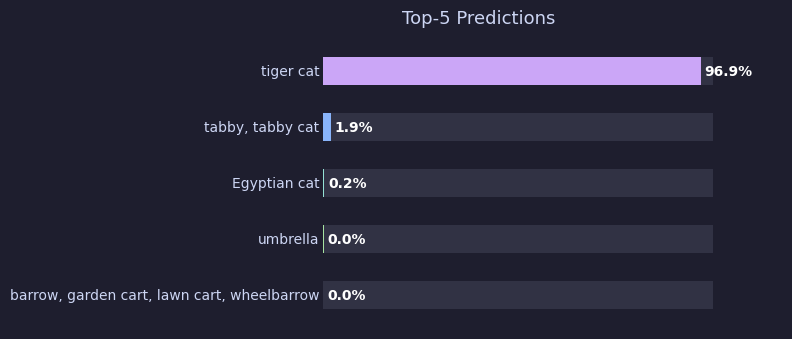

In [105]:
import matplotlib.pyplot as plt
import numpy as np

with open(LABELS_PATH, 'r') as f:
    index_to_label = json.load(f)

labels = [index_to_label[str(int(idx))] for idx in top5_indices]
probs_np = np.array(top5_probabilities, dtype=float)

labels = labels[::-1]
probs_np = probs_np[::-1]

fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bar_h = 0.5
colors = ['#cba6f7', '#89b4fa', '#94e2d5', '#a6e3a1', '#f9e2af'][::-1]

for i, (label, prob, color) in enumerate(zip(labels, probs_np, colors)):
    ax.barh(i, 1.0, height=bar_h, color='#313244', left=0)
    ax.barh(i, prob,  height=bar_h, color=color,    left=0)
    ax.text(prob + 0.01, i, f'{prob*100:.1f}%', va='center', ha='left',
            color='white', fontsize=10, fontweight='bold')
    ax.text(-0.01, i, label, va='center', ha='right',
            color='#cdd6f4', fontsize=10)

ax.set_xlim(-0.38, 1.18)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.axis('off')
ax.set_title('Top-5 Predictions', color='#cdd6f4', fontsize=13, pad=10)

plt.tight_layout()
plt.show()


### Visualisations

### Intermediate Stage Outputs

To power the visualizations below we run one extra forward pass that captures the output tensor after each of the four block groups. ResNet-50's spatial/channel progression at each stage is:

| Stage | Channels | Spatial |
|---|---|---|
| 1 | 256 | 56 × 56 |
| 2 | 512 | 28 × 28 |
| 3 | 1024 | 14 × 14 |
| 4 | 2048 | 7 × 7 |

The final `7×7×2048` tensor (before GAP) is also saved as `pre_gap` — it is the feature map used directly by CAM.

In [106]:
def resnet_model_with_intermediates(
    x: jnp.ndarray, # (N, 3, 224, 224)
    params: dict
):
    x = resnet_stem(x, params)

    num_layers = [3, 4, 6, 3]
    start = 0
    stage_outputs = {}

    for i in range(4):
        end = start + num_layers[i]
        block_group_params = params['blocks'][start:end]
        stride = 1 if i == 0 else 2
        x = resnet_block_group(x, block_group_params, stride=stride)
        stage_outputs[i + 1] = x
        start = end

    pre_gap = x
    x = jnp.mean(x, axis=(2, 3))
    logits = jnp.dot(x, params['fc']['weight'].T) + params['fc']['bias']
    return logits, stage_outputs, pre_gap

_, stage_outputs, pre_gap = resnet_model_with_intermediates(image, m)

for k, v in stage_outputs.items():
    print(f"Stage {k}: {v.shape}")
print(f"pre_gap:  {pre_gap.shape}")


Stage 1: (1, 256, 56, 56)
Stage 2: (1, 512, 28, 28)
Stage 3: (1, 1024, 14, 14)
Stage 4: (1, 2048, 7, 7)
pre_gap:  (1, 2048, 7, 7)


### Class Activation Map (CAM)

ResNet-50 is one of the original architectures for which exact **Class Activation Mapping** (Zhou et al. 2016) works — because it ends with GAP directly into a linear classifier, with no hidden FC layers in between.

So the spatial activation map is just a **weighted sum of the 2048 pre-GAP channels**, weighted by the classifier weights for the target class. We upsample the resulting `7×7` map back to `224×224` for overlay.

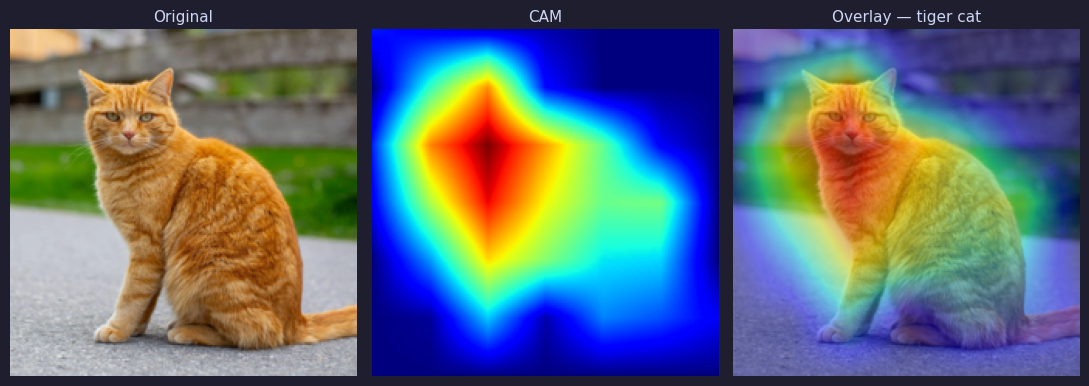

In [107]:
import scipy.ndimage

top_class = int(top5_indices[0])

feat = np.array(pre_gap[0], dtype=np.float32)                        # (2048, 7, 7)
w    = np.array(m['fc']['weight'][top_class], dtype=np.float32)      # (2048,)

cam = np.einsum('chw,c->hw', feat, w)                                # (7, 7)
cam = np.maximum(cam, 0)
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
cam = scipy.ndimage.zoom(cam, 224 / 7, order=1)                      # (224, 224)

img_arr = np.array(Image.open(IMAGE_PATH).convert("RGB").resize((224, 224)))

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
fig.patch.set_facecolor('#1e1e2e')
for ax in axes:
    ax.set_facecolor('#1e1e2e')

axes[0].imshow(img_arr)
axes[0].set_title("Original", color='#cdd6f4', fontsize=11)
axes[1].imshow(cam, cmap='jet')
axes[1].set_title("CAM", color='#cdd6f4', fontsize=11)
axes[2].imshow(img_arr)
axes[2].imshow(cam, cmap='jet', alpha=0.45)
axes[2].set_title(f"Overlay — {index_to_label[str(top_class)]}", color='#cdd6f4', fontsize=11)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


### Multi-Scale Feature Maps

Each stage of ResNet halves the spatial resolution while doubling the channel count (except Stage 1 which only expands channels). The grid below shows the **most active channel** from each stage's output feature map — a visual account of the network transitioning from fine-grained edge detectors to coarse, object-level semantic activations.

This spatial compression is the direct result of the stride-2 downsampling applied in the first bottleneck of each group, and is why ResNet's skip connections must include projection shortcuts at those boundaries.

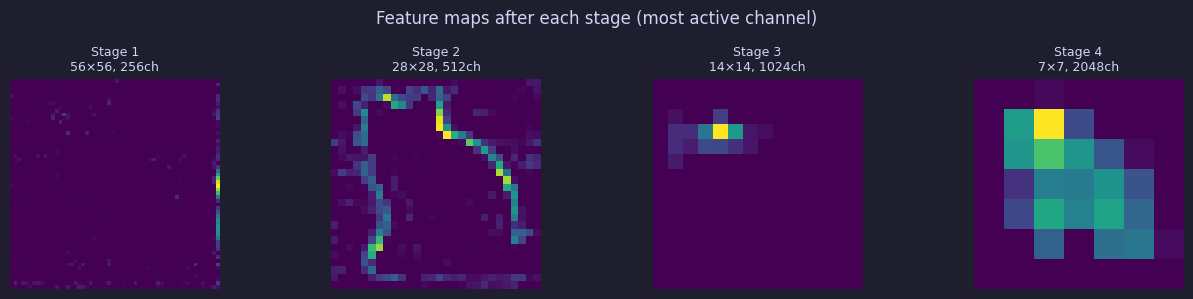

In [ ]:
stage_keys = sorted(stage_outputs.keys())

fig, axes = plt.subplots(1, len(stage_keys), figsize=(13, 3))
fig.patch.set_facecolor('#1e1e2e')

for ax, s in zip(axes, stage_keys):
    feat = np.array(stage_outputs[s][0], dtype=np.float32)          # (C, H, W)
    ch   = np.argmax(feat.max(axis=(1, 2)))                         # most-active channel
    fmap = feat[ch]
    ax.imshow(fmap, cmap='viridis')
    ax.set_title(
        f"Stage {s}\n{feat.shape[1]}×{feat.shape[2]}, {feat.shape[0]}ch",
        fontsize=9, color='#cdd6f4'
    )
    ax.axis('off')

plt.suptitle('Feature maps after each stage (most active channel)', fontsize=12, color='#cdd6f4')
plt.tight_layout()
plt.show()


### Stem Filter Visualisation

ResNet's 7×7 stem conv is one of the largest first-layer kernels in common CNN architectures — EfficientNet uses 3×3, VGG uses 3×3, but ResNet uses 7×7 to cover a wide initial receptive field before spatial resolution is aggressively halved.

When visualised as RGB patches, these 64 filters should resemble **Gabor-like edge detectors** — oriented edges, colour gradients, and blob detectors — which are known to be the typical patterns learned by CNNs in their first layer regardless of the task.

Each filter `(7, 7, 3)` is min-max normalised independently so subtle filters are visible and colours are not blown out by outliers.

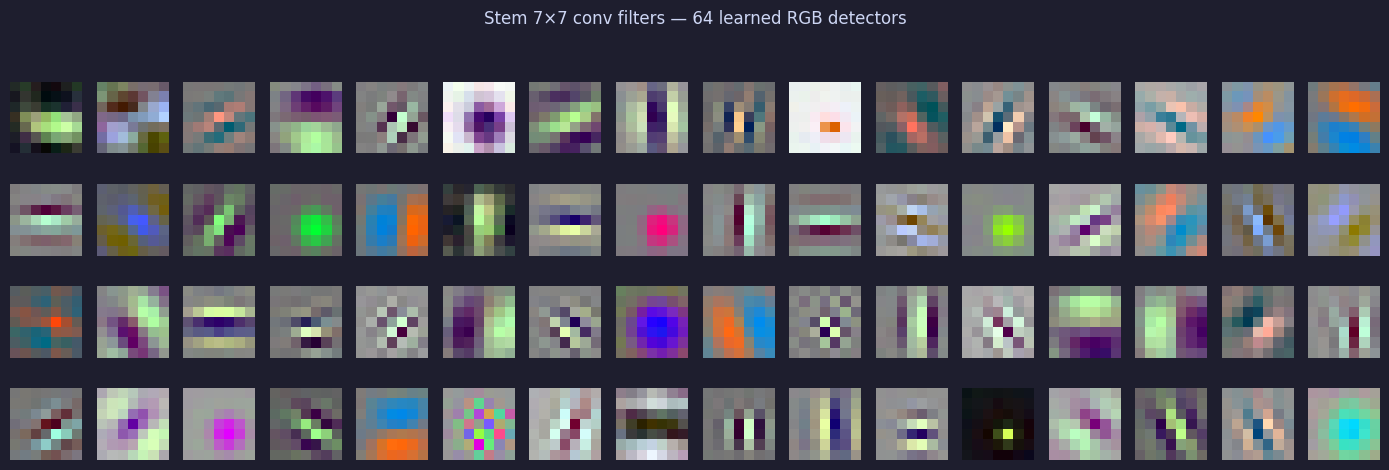

In [ ]:
filters = np.array(m['conv'], dtype=np.float32)   # (64, 3, 7, 7)

n_filters = filters.shape[0]
cols = 16
rows = n_filters // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 1.2))
fig.patch.set_facecolor('#1e1e2e')

for idx in range(n_filters):
    ax = axes[idx // cols][idx % cols]
    f  = filters[idx].transpose(1, 2, 0)            # (7, 7, 3) — HWC for imshow
    f  = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f, interpolation='nearest')
    ax.axis('off')

plt.suptitle('Stem 7x7 conv filters — 64 learned RGB detectors', fontsize=12, color='#cdd6f4', y=1.01)
plt.tight_layout()
plt.show()
